# LLM and literature
The goal of our project was to test the performance of large language models on the literature contained in *Project Gutenberg*, with special regards of differences in the language accuracies. We tested how different challenges changed the accuracy of the model. Accuracy in this case meant the capability of the model to guess from which book a certain text slice was. 

For that we first needed our basic programm to use for the different tests. 

## Basics

### Used Libraries

In [84]:
import os
import random
import re
import csv
import torch
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer
import matplotlib.pyplot as plt
import string
import copy

### Fixed Variables
These are variables that are used, at several points. When changed the whole code should be executed again, as they influence all following parts. The current values were chosen to be a balance between performance and sufficient results. 

In [20]:
NUM_TESTED_BOOKS = 100
SNIPPET_LENGTH = 1000
MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"
DATASET_NAME = "manu/project_gutenberg"
OUTPUT_FILE = "book_reasoning.txt"
CSV_FILE = "translated_books.csv"

### Important Methods
Methods that are used repeatedly throughout the program, optional parameters should make them more flexible, avoiding to use several similar ones. 

First one is to read the dataset, in the given language and import the books from there. Books that are translations are being excluded. 

In [16]:
def is_a_translation(text):
    translator_match = re.search(r"Translator:\s*(.*)", text, re.IGNORECASE)
    return translator_match is not None


def load_books(language):
    books = []
    dataset = load_dataset(DATASET_NAME, split=language, streaming= True)
    seen_titles = set()
    iterator = iter(dataset)
    
    while len(books) < NUM_TESTED_BOOKS:
        try: 
            item = next(iterator)
            text = item["text"]
            title = "Unknown Title"

            # Skips translations
            if is_a_translation(text) is True:
                continue
            
            # Searches for "Title" in the header
            title_match = re.search(
                r"Title:\s*(.*?)(?=\r?\n\w+:|\r?\n\r?\n)",
                text,
                re.IGNORECASE | re.DOTALL,
            )

            if title_match: 
                title = re.sub(r"\s+", " ", title_match.group(1)).strip()
                title = title.lower()

            # Skips books with recurring titles or no title
            if title == "Unknown Title" or title in seen_titles:
                continue

            snippet_start = len(text) // 2
            snippet_end = snippet_start + SNIPPET_LENGTH
            snippet = text[snippet_start:snippet_end].strip()

            seen_titles.add(title)
            books.append({"title":title, "text":snippet})

        except StopIteration:
            print("Reached end of dataset.")
            break

    print(f"Loaded {NUM_TESTED_BOOKS} in {language}")
    return books


Next a method to create the multiple choice questions that the model gets asked. The wrong answers coming from the pool of possible titles from the database. 

In [4]:
def create_multiple_choice_questions(books):
    question_set = []
    all_titles = [book["title"] for book in books]

    for book in books:
        correct_title = book["title"]

        wrong_choices = [t for t in all_titles if t != correct_title]

        if len(wrong_choices) < 3:
            raise ValueError("Not enough titles to create questions")
        
        choices = random.sample(wrong_choices, 3) + [correct_title]
        random.shuffle(choices)

        correct_letter = chr(65 + choices.index(correct_title))

        question_set.append({"snippet": book["text"], "choices": choices, "correct_letter": correct_letter, "correct_title": correct_title})

    print("Created Questions")
    return question_set

In [100]:
def testing_accuracy(model, tokenizer, question_set, reasoning=False):
    correct_predictions = 0
    failed_parses = 0
    incorrect_predictions = 0

    per_item = []

    for i, item in enumerate(question_set):
        prompt_choices = "\n".join(
            f"{chr(65 + idx)}) {choice}" for idx, choice in enumerate(item["choices"])
        )

        if reasoning:
            prompt = (
                "You are a helpful literature assistant. Your task is to identify to which book a text snippet belongs to.\n"
                "Structure your response exactly like this. Do NOT use any other formatting:\n"
                "Answer: [Single answer choice: A, B, C or D]\n"
                "Explanation: [A brief 1-2 sentence explanation]\n\n"
                f"Text Snippet:\n\"\"\"\n{item['snippet']}\n\"\"\"\n\n"
                f"Which book is this snippet from?\n{prompt_choices}\n\n"
                "Provide your answer using the correct format."
            )
        else:
            prompt = (
                "You are a helpful literature assistant. Your task is to identify to which book a text snippet belongs to.\n"
                "Respond only (!) with the single letter choice (A, B, C or D), corresponding to the correct book.\n"
                "Do not output anything else.\n"
                f"\n\"\"\"\n{item['snippet']}\n\"\"\"\n\n"
                f"Which book is this snippet from?\n{prompt_choices}\n\n"
                "Answer (A/B/C/D):"
            )

        messages = [{"role": "user", "content": prompt}]
        text_input = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )

        model_inputs = tokenizer([text_input], return_tensors="pt").to(model.device)

        with torch.no_grad():
            generated_ids = model.generate(
                **model_inputs,
                max_new_tokens=4 if not reasoning else 80,
                temperature=0.1,
                do_sample=False,
            )

        # keep only newly generated tokens
        generated_ids = [
            output_ids[len(input_ids):]
            for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
        ]

        response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()

        predicted_letter = None
        explanation = ""

        if reasoning:
            # Expect format: Answer: X  \n Explanation: ...
            m_letter = re.search(r"Answer:\s*([A-D])", response, re.IGNORECASE)
            m_expl = re.search(r"Explanation:\s*(.*)", response, re.IGNORECASE | re.DOTALL)
            if m_letter:
                predicted_letter = m_letter.group(1).upper()
            if m_expl:
                explanation = m_expl.group(1).strip()
        else:
            m = re.search(r"[A-D]", response.upper())
            if m:
                predicted_letter = m.group(0)

        if predicted_letter:
            if predicted_letter == item["correct_letter"].upper():
                correct_predictions += 1
            else:
                incorrect_predictions += 1
        else:
            failed_parses += 1

        per_item.append({
            "index": i + 1,
            "predicted_letter": predicted_letter or "PARSE_FAIL",
            "correct_letter": item["correct_letter"].upper(),
            "explanation": explanation,
            "correct_title": item.get("correct_title", ""),
            "response_raw": response,
        })

    # write a clear, human-readable reasoning file
    with open(OUTPUT_FILE, "w", encoding="utf-8") as f_out:
        f_out.write("Book Reasoning Results\n")
        f_out.write("======================\n\n")
        f_out.write(f"Total Questions: {len(question_set)}\n")
        f_out.write(f"Correct Predictions: {correct_predictions}\n")
        f_out.write(f"Incorrect Predictions: {incorrect_predictions}\n")
        f_out.write(f"Failed Parses: {failed_parses}\n\n")
        f_out.write("Per-question details (only key fields shown):\n\n")

        for item in per_item:
            f_out.write(f"Question {item['index']}\n")
            f_out.write(f"Guessed Letter: {item['predicted_letter']}\n")
            f_out.write(f"Correct Letter: {item['correct_letter']}\n")
            f_out.write(f"Correct Title: {item['correct_title']}\n")
            if item["explanation"]:
                f_out.write("Explanation:\n")
                # indent explanation lines for readability
                for line in item["explanation"].splitlines():
                    f_out.write(f"  {line.strip()}\n")
            else:
                f_out.write("Explanation: (none parsed)\n")
            f_out.write("\n")

    return {
        "correct": correct_predictions,
        "incorrect": incorrect_predictions,
        "failed": failed_parses
    }


For later tests we are going to add noise into the text. For this the following method can be used.

In [85]:
def add_noise(books, percentage):
    if percentage <= 0:
        return books
    
    book_noise = []
    random_pool = string.ascii_letters 

    for book in books:
        book_copy = copy.deepcopy(book)
        text = book_copy["text"]

        text_chars = list(text)
        num_chars_to_change = int(len(text_chars) * (percentage / 100.0))

        indices_to_replace = random.sample(range(len(text_chars)), num_chars_to_change)

        for idx in indices_to_replace:
            text_chars[idx] = random.choice(random_pool)

        book_copy["text"] = "".join(text_chars)
        book_noise.append(book_copy)
    print("Added Noise")
    return book_noise    

## Loading Model

In [7]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype="auto",
    device_map="auto",
)

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu and disk.


# Building the Datasets
For the different tasks later we need datasets of books with their titles. 

In [58]:
english_books = load_books("en")
english_questions = create_multiple_choice_questions(english_books)

german_books = load_books("de")
german_questions = create_multiple_choice_questions(german_books)

french_books = load_books("fr")
french_questions = create_multiple_choice_questions(french_books)

dutch_books = load_books("nl")
dutch_questions = create_multiple_choice_questions(dutch_books)

italian_books = load_books("it")
italian_questions = create_multiple_choice_questions(italian_books)


Resolving data files:   0%|          | 0/52 [00:00<?, ?it/s]

Loaded 100 in en
Created Questions


Resolving data files:   0%|          | 0/52 [00:00<?, ?it/s]

Loaded 100 in de
Created Questions


Resolving data files:   0%|          | 0/52 [00:00<?, ?it/s]

Loaded 100 in fr
Created Questions


Resolving data files:   0%|          | 0/52 [00:00<?, ?it/s]

Loaded 100 in nl
Created Questions


Resolving data files:   0%|          | 0/52 [00:00<?, ?it/s]

Loaded 100 in it
Created Questions


For one part of the tests, we need a bit different dataset. This dataset should consist of german translations of english books with the english title.

In [28]:
def is_translation_from_english(text, author=""):
    """
    Detect whether a German Gutenberg text looks like a translation from English.
    """
    header_area = text[:4000].lower()

    german_translation_patterns = [
        r"aus\s+dem\s+englischen",
        r"aus\s+d\.\s+englischen",
        r"übersetzung\s+aus\s+dem\s+englischen",
        r"uebersetzung\s+aus\s+dem\s+englischen",
        r"übersetzt\s+aus\s+dem\s+englischen",
        r"uebersetzt\s+aus\s+dem\s+englischen",
        r"übertragen\s+aus\s+dem\s+englischen",
        r"uebertragen\s+aus\s+dem\s+englischen",
        r"vom\s+englischen\s+ins\s+deutsche",
        r"deutsch\s+von.*englischen",
    ]

    for pattern in german_translation_patterns:
        if re.search(pattern, header_area):
            return True, "Recognized via phrase: 'aus dem Englischen'"

    has_translator = "translator:" in header_area or "übersetzer:" in header_area or "uebersetzer:" in header_area

    if has_translator and author:
        famous_english_authors = {
            "shakespeare", "dickens", "twain", "poe", "conan doyle", "wilde", "london", "kipling",
            "wells", "austen", "bront", "shelley", "stoker", "carroll", "melville", "hawthorne",
            "swift", "defoe", "hardy", "thackeray", "alcott", "cooper", "irving", "emerson", "whitman"
        }

        author_clean = author.lower()
        for eng_author in famous_english_authors:
            if eng_author in author_clean:
                return True, f"English author ({author}) with translator metadata."

    return False, ""


def parse_metadata_and_id(text):
    """
    Extract Gutenberg ID, title, and author from a German Gutenberg header.
    """
    title = "Unknown Title"
    author = "Unknown Author"
    gutenberg_id = "Unknown ID"

    id_match = re.search(r"\[eBook\s*#?(\d+)\]", text, re.IGNORECASE)
    if id_match:
        gutenberg_id = id_match.group(1)

    title_match = re.search(
        r"Title:\s*(.*?)(?=\r?\n\w+:|\r?\n\r?\n)",
        text,
        re.IGNORECASE | re.DOTALL,
    )
    if title_match:
        raw_title = title_match.group(1)
        title = re.sub(r"\s+", " ", raw_title).strip()

    author_match = re.search(
        r"Author:\s*(.*?)(?=\r?\n\w+:|\r?\n\r?\n)",
        text,
        re.IGNORECASE | re.DOTALL,
    )
    if author_match:
        raw_author = author_match.group(1)
        author = re.sub(r"\s+", " ", raw_author).strip()

    return gutenberg_id, title, author



def create_translation_csv():
    dataset_de = load_dataset("manu/project_gutenberg", split="de")

    translations = []
    seen_ids = set()

    for item in dataset_de:
        text = item["text"]
        gutenberg_id, title, author = parse_metadata_and_id(text)
        matched, reason = is_translation_from_english(text, author)

        if matched and gutenberg_id != "Unknown ID" and gutenberg_id not in seen_ids:
            seen_ids.add(gutenberg_id)
            translations.append({
                "Gutenberg ID": gutenberg_id,
                "Deutscher Titel": title,
                "Autor": author,
                "Erkennungsgrund": reason,
                "Originaler Englischer Titel": ""
            })

    with open(CSV_FILE, mode="w", encoding="utf-8-sig", newline="") as f:
        writer = csv.DictWriter(
            f,
            fieldnames=["Gutenberg ID", "Deutscher Titel", "Autor", "Erkennungsgrund", "Originaler Englischer Titel (Manuell)"],
            delimiter=";"
        )
        writer.writeheader()
        for row in translations:
            writer.writerow(row)



In [27]:
if os.path.exists(CSV_FILE):
    print(f"Using existing CSV: {CSV_FILE}")
else:
    create_translation_csv()

Resolving data files:   0%|          | 0/52 [00:00<?, ?it/s]

data/de-00001-of-00003-44c9c3b458e2eef3.(…):   0%|          | 0.00/135M [00:00<?, ?B/s]

data/de-00002-of-00003-084edb3f286e612c.(…):   0%|          | 0.00/148M [00:00<?, ?B/s]

data/en-00000-of-00052-7cda8f63c262acf8.(…):   0%|          | 0.00/197M [00:00<?, ?B/s]

data/en-00001-of-00052-5c2b3fd5e60f0124.(…):   0%|          | 0.00/209M [00:00<?, ?B/s]

...

Generating pl split:   0%|          | 0/34 [00:00<?, ? examples/s]

Generating pt split:   0%|          | 0/1111 [00:00<?, ? examples/s]

Generating ru split:   0%|          | 0/6 [00:00<?, ? examples/s]

Generating sv split:   0%|          | 0/388 [00:00<?, ? examples/s]

Generating zh split:   0%|          | 0/437 [00:00<?, ? examples/s]

The csv file now contains the german titles. By hand we mapped the original english titles to it. For some books that were translations no original title could be found. Therefore in the end we ended on 24 books. 

In [33]:
def load_manually_mapped_books_csv():
    """
    Load the manually mapped Gutenberg IDs and their German/English titles.
    The CSV uses ';' as delimiter.
    """
    print(f"Loading manual mappings from {CSV_FILE}...")
    title_lookup = {}

    try:
        with open(CSV_FILE, mode="r", encoding="utf-8-sig") as f:
            reader = csv.DictReader(f, delimiter=";")
            for row in reader:
                book_id = row["Gutenberg ID"].strip()
                german_title = row["Deutscher Titel"].strip()
                english_title = row["Originaler Englischer Titel"].strip()

                title_lookup[book_id] = {
                    "english_title": english_title,
                    "german_title": german_title,
                }
    except FileNotFoundError:
        print(f"Error: {CSV_FILE} not found.")

    return title_lookup


In [35]:
title_lookup = load_manually_mapped_books_csv()

all_english_titles = [
    entry["english_title"]
    for entry in title_lookup.values()
    if entry.get("english_title", "").strip()
]

print(f"Loaded {len(title_lookup)} title mappings.")


Loading manual mappings from translated_books.csv...
Loaded 24 title mappings.


The German Gutenberg dataset is streamed book by book.  
For each book, we extract the Gutenberg ID and title information, match it to the CSV entry, and create a short text snippet.

In [57]:
dataset_de = load_dataset("manu/project_gutenberg", split="de", streaming=True)

german_mismatched_books = []
seen_ids = set()
iterator = iter(dataset_de)

while len(german_mismatched_books) < len(title_lookup):
    try:
        item = next(iterator)
        text = item["text"]

        gutenberg_id, german_title, author = parse_metadata_and_id(text)

        if gutenberg_id == "Unknown ID":
            continue

        mapping = title_lookup.get(gutenberg_id)
        if not mapping:
            continue

        english_title = mapping["english_title"]
        german_title = mapping["german_title"]

        if gutenberg_id in seen_ids:
            continue
        seen_ids.add(gutenberg_id)

        snippet = text[1000:1000 + SNIPPET_LENGTH].strip()

        german_mismatched_books.append({
            "german_title": german_title,
            "english_title": english_title,
            "text_snippet": snippet,
        })


    except StopIteration:
        print("Dataset stream finished. Not all German books listed in the CSV could be loaded.")
        break

print(f"Dataset preparation done. Loaded total of {len(german_books)} books.")

Resolving data files:   0%|          | 0/52 [00:00<?, ?it/s]

Dataset stream finished. Not all German books listed in the CSV could be loaded.
Dataset preparation done. Loaded total of 23 books.


# Accuracy Analysis

# Base Accuracy
The baseline of accuracy of LLM models on recognizing literature, was done on an all english literature and english titles, as it is to be expected this to be the most accurate the model can become.  

In [46]:
english_results = testing_accuracy(model, tokenizer, english_questions)

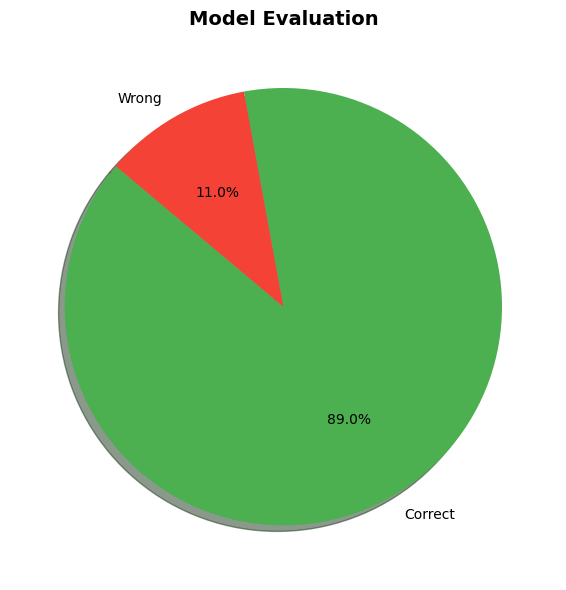

In [51]:

labels = ['Correct', 'Wrong', 'Parsing Fehler']
sizes = [english_results['correct'], english_results['incorrect'], english_results['failed']]
colors = ['#4CAF50', '#F44336', '#FF9800'] # Green, Red, Orange

filtered_labels = [l for l, s in zip(labels, sizes) if s > 0]
filtered_sizes = [s for s in sizes if s > 0]
filtered_colors = [c for c, s in zip(colors, sizes) if s > 0]

plt.figure(figsize=(6, 6))
plt.pie(
    filtered_sizes, 
    labels=filtered_labels, 
    colors=filtered_colors, 
    autopct='%1.1f%%', 
    startangle=140, 
    shadow=True
)

plt.title('Model Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()

# Save or show the chart
plt.savefig('evaluation_results.png')
plt.show()




# Different Language Accuracy

In [59]:
german_accuracy = testing_accuracy(model, tokenizer, german_questions)
french_accuracy = testing_accuracy(model, tokenizer, french_questions)
italian_accuracy = testing_accuracy(model, tokenizer, italian_questions)
dutch_accuracy = testing_accuracy(model, tokenizer, dutch_questions)

Text(0, 0.5, 'Accuracy (%)')

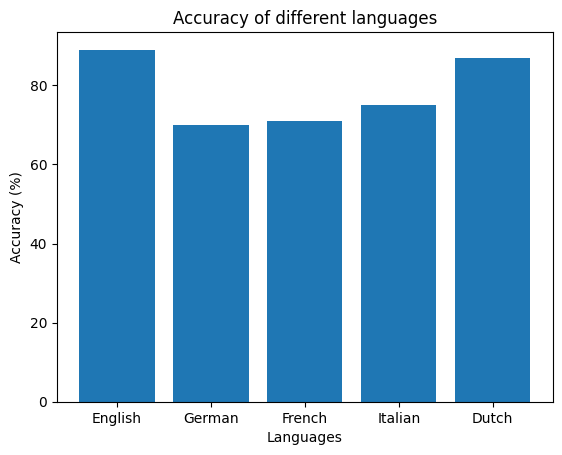

In [60]:
languages = ['English', 'German', 'French', 'Italian', 'Dutch']
accuracy = [english_results['correct'], german_accuracy['correct'], french_accuracy['correct'], italian_accuracy['correct'], dutch_accuracy['correct']]

plt.bar(languages, accuracy)
plt.title("Accuracy of different languages")
plt.xlabel("Languages")
plt.ylabel("Accuracy (%)")


# Accuracy Text/Title Mismatch


In [76]:
correct_predictions_de = 0
incorrect_predictions_de = 0
failed_parses_de = 0

for i, item in enumerate(german_mismatched_books):
    # Multiple choice
    correct_title = item["english_title"]
    wrong_choices = [t for t in all_english_titles if t != correct_title]

    if len(wrong_choices) < 3:
        raise ValueError("Not enough titles to create question choices for item {}".format(i))

    choices = random.sample(wrong_choices, 3) + [correct_title]
    random.shuffle(choices)
    correct_letter = chr(65 + choices.index(correct_title))

    prompt_choices = "\n".join(
        f"{chr(65 + idx)}) {choice}" for idx, choice in enumerate(choices)
    )

    system_prompt = "You are a helpful assistant. Read the German book text and identify the English original title."
    user_prompt = (
        f"Here is the beginning of a German book:\n\n{item['text_snippet']}\n\n"
        "Which is the English original title of this book? Choose the correct option:\n"
        f"{prompt_choices}\n\n"
        "Answer ONLY with the corresponding capital letter (A, B, C, or D)."
    )

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]

    text_input = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    model_inputs = tokenizer([text_input], return_tensors="pt").to(model.device)

    with torch.no_grad():
        generated_ids = model.generate(
            **model_inputs,
            max_new_tokens=5,
            temperature=0.1,
            do_sample=False,
        )

    generated_ids = [
        output_ids[len(input_ids):]
        for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
    ]

    response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0].strip().upper()

    predicted_letter_match = re.search(r"[A-D]", response)
        
    if predicted_letter_match:
        predicted_letter = predicted_letter_match.group(0)
        
        if predicted_letter == correct_letter:
            correct_predictions_de += 1
        else: 
            incorrect_predictions_de += 1
    else:
        failed_parses_de += 1
        



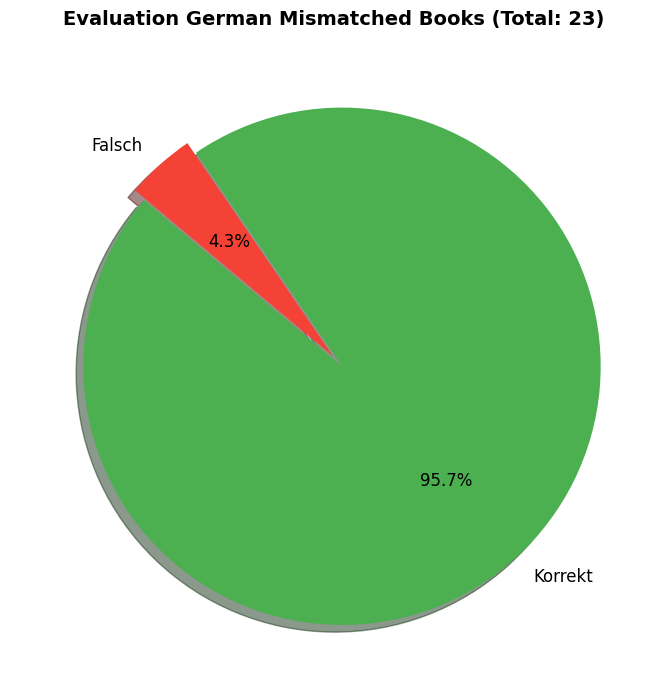

In [75]:

# Prepare data categories
labels = ['Korrekt', 'Falsch', 'Parsing Fehler']
sizes = [correct_predictions_de, incorrect_predictions_de, failed_parses_de]
colors = ['#4CAF50', '#F44336', '#FF9800'] # Green, Red, Orange
explode = (0.05, 0, 0)  # slightly separate the 'Korrekt' slice for visual emphasis

# Clean data: Filter out categories with 0 occurrences to prevent chart overlap clutter
filtered_labels = [lbl for lbl, sz in zip(labels, sizes) if sz > 0]
filtered_sizes = [sz for sz in sizes if sz > 0]
filtered_colors = [col for col, sz in zip(colors, sizes) if sz > 0]

# Generate plot if there is data
if sum(sizes) > 0:
    plt.figure(figsize=(7, 7))
    plt.pie(
        filtered_sizes, 
        labels=filtered_labels, 
        colors=filtered_colors, 
        autopct='%1.1f%%', 
        startangle=140, 
        explode=explode[:len(filtered_sizes)],
        shadow=True,
        textprops={'fontsize': 12}
    )
    
    plt.title(f'Evaluation German Mismatched Books (Total: {sum(sizes)})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    # Save chart as image and display it
    plt.savefig('german_eval_results.png', dpi=300)
    plt.show()
else:
    print("No evaluation data collected to draw the chart.")

# Testing on noise
Last test finding out how much of a text can be wrong and still be found by the model.

In [86]:
english_noise_accuracy = []
german_noise_accuracy = []
french_noise_accuracy = []
italian_noise_accuracy = []
dutch_noise_accuracy = []

noise_levels = []

noise = 0

for noise in range(0, 51, 5): 
    print (f"Noise: {noise}%")
    noise_levels.append(noise)

    print("Testing English books with noise...")
    noisy_english_books = add_noise(english_books, noise)
    noisy_english_questions = create_multiple_choice_questions(noisy_english_books)
    english_results = testing_accuracy(model, tokenizer, noisy_english_questions)
    english_noise_accuracy.append(english_results['correct'])
    
    print("Testing German books with noise...")
    noisy_german_books = add_noise(german_books, noise)
    noisy_german_questions = create_multiple_choice_questions(noisy_german_books)
    german_results = testing_accuracy(model, tokenizer, noisy_german_questions)
    german_noise_accuracy.append(german_results['correct'])
    
    print("Testing French books with noise...")
    noisy_french_books = add_noise(french_books, noise)
    noisy_french_questions = create_multiple_choice_questions(noisy_french_books)
    french_results = testing_accuracy(model, tokenizer, noisy_french_questions)
    french_noise_accuracy.append(french_results['correct'])
    
    print("Testing Italian books with noise...")
    noisy_italian_books = add_noise(italian_books, noise)
    noisy_italian_questions = create_multiple_choice_questions(noisy_italian_books)
    italian_results = testing_accuracy(model, tokenizer, noisy_italian_questions)
    italian_noise_accuracy.append(italian_results['correct'])
    
    print("Testing Dutch books with noise...")
    noisy_dutch_books = add_noise(dutch_books, noise)
    noisy_dutch_questions = create_multiple_choice_questions(noisy_dutch_books)
    dutch_results = testing_accuracy(model, tokenizer, noisy_dutch_questions)
    dutch_noise_accuracy.append(dutch_results['correct']) 

Noise: 0%
Testing English books with noise...
Created Questions
Testing German books with noise...
Created Questions
Testing French books with noise...
Created Questions
Testing Italian books with noise...
Created Questions
Testing Dutch books with noise...
Created Questions
Noise: 5%
Testing English books with noise...
Added Noise
Created Questions
Testing German books with noise...
Added Noise
Created Questions
Testing French books with noise...
Added Noise
Created Questions
Testing Italian books with noise...
Added Noise
Created Questions
Testing Dutch books with noise...
Added Noise
Created Questions
Noise: 10%
Testing English books with noise...
Added Noise
Created Questions
Testing German books with noise...
Added Noise
Created Questions
Testing French books with noise...
Added Noise
Created Questions
Testing Italian books with noise...
Added Noise
Created Questions
Testing Dutch books with noise...
Added Noise
Created Questions
Noise: 15%
Testing English books with noise...
Adde

In [92]:
print("Noise testing completed. Plotting results...")
print(f"Noise Levels: {noise_levels}")
print(f"English Accuracy: {english_noise_accuracy}")
print(f"German Accuracy: {german_noise_accuracy}")
print(f"French Accuracy: {french_noise_accuracy}")
print(f"Italian Accuracy: {italian_noise_accuracy}")
print(f"Dutch Accuracy: {dutch_noise_accuracy}")

Noise testing completed. Plotting results...
Noise Levels: [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
English Accuracy: [89, 88, 81, 83, 79, 67, 64, 51, 47, 50, 38]
German Accuracy: [67, 74, 62, 59, 57, 53, 45, 44, 31, 36, 23]
French Accuracy: [70, 66, 61, 60, 48, 38, 36, 34, 31, 24, 30]
Italian Accuracy: [63, 64, 53, 55, 50, 50, 38, 41, 30, 27, 25]
Dutch Accuracy: [83, 78, 77, 67, 62, 49, 49, 47, 34, 26, 25]


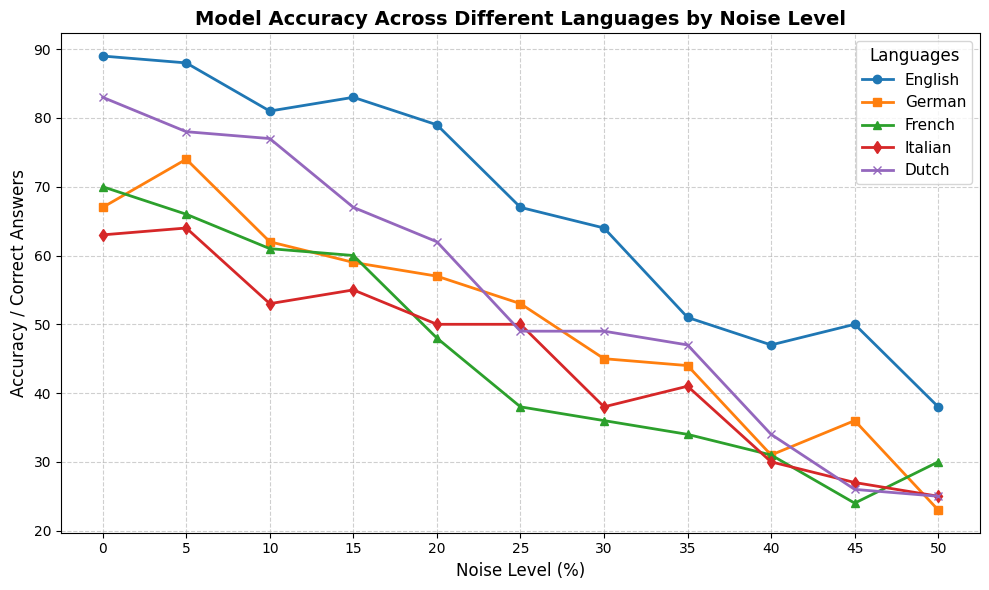

In [89]:
plt.figure(figsize=(10, 6))

plt.plot(noise_levels, english_noise_accuracy, marker='o', label='English', linewidth=2)
plt.plot(noise_levels, german_noise_accuracy, marker='s', label='German', linewidth=2)
plt.plot(noise_levels, french_noise_accuracy, marker='^', label='French', linewidth=2)
plt.plot(noise_levels, italian_noise_accuracy, marker='d', label='Italian', linewidth=2)
plt.plot(noise_levels, dutch_noise_accuracy, marker='x', label='Dutch', linewidth=2)

plt.title('Model Accuracy Across Different Languages by Noise Level', fontsize=14, fontweight='bold')
plt.xlabel('Noise Level (%)', fontsize=12)
plt.ylabel('Accuracy / Correct Answers', fontsize=12)

plt.xticks(range(0, 51, 5))

plt.grid(True, linestyle='--', alpha=0.6)

plt.legend(title="Languages", fontsize=11, title_fontsize=12, loc='best')

plt.tight_layout()
plt.show()

# Analyzing Reasoning

In [97]:
NUM_TESTED_BOOKS = 20
OUTPUT_FILE = "book_reasoning_english.txt"

In [ ]:
smaller_english_books = load_books("en")
fewer_english_questions = create_multiple_choice_questions(smaller_english_books)
testing_accuracy(model, tokenizer, fewer_english_questions, reasoning=True)

Resolving data files:   0%|          | 0/52 [00:00<?, ?it/s]

Loaded 20 in en
Created Questions


In [95]:
smaller_german_books = load_books("de")
fewer_german_questions = create_multiple_choice_questions(smaller_german_books)
testing_accuracy(model, tokenizer, fewer_german_questions, reasoning=True)

Resolving data files:   0%|          | 0/52 [00:00<?, ?it/s]

Loaded 20 in de
Created Questions


{'correct': 5, 'incorrect': 15, 'failed': 0}

In [ ]:
testing_accuracy(model, tokenizer, french_questions, reasoning=True)